# Impact of Non-IID Data on Federated Learning

## Objective

This notebook investigates the impact of non-IID client distributions on Federated Learning performance.

Unlike the IID experiment, each client receives data from only two digit classes, creating an extreme heterogeneous setting.


In [32]:
import copy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset


## Environment Setup

In [33]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu


## Experimental Configuration

- Number of Clients: 5
- Communication Rounds: 5
- Local Epochs: 1
- Non-IID Distribution


In [34]:
NUM_CLIENTS = 5
ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 64
LR = 0.001


## Non-IID Dataset Construction

Client Distribution:

- Client 1 → Digits (0,1)
- Client 2 → Digits (2,3)
- Client 3 → Digits (4,5)
- Client 4 → Digits (6,7)
- Client 5 → Digits (8,9)

This represents an extreme non-IID scenario.


In [35]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

targets = train_dataset.targets

client_digit_groups = [(0,1),(2,3),(4,5),(6,7),(8,9)]

client_datasets = []

for d1, d2 in client_digit_groups:

    indices = ((targets == d1) | (targets == d2)).nonzero(as_tuple=True)[0]

    subset = Subset(train_dataset, indices)

    client_datasets.append(subset)

    print(f'Client ({d1},{d2}) -> {len(indices)} samples')


Client (0,1) -> 12665 samples
Client (2,3) -> 12089 samples
Client (4,5) -> 11263 samples
Client (6,7) -> 12183 samples
Client (8,9) -> 11800 samples


In [36]:
client_loaders = [
    DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)
    for ds in client_datasets
]

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [37]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,32,3)
        self.conv2 = nn.Conv2d(32,64,3)
        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(64*12*12,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self,x):

        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0),-1)

        x = torch.relu(self.fc1(x))

        return self.fc2(x)


## FedAvg Implementation

In [38]:
def train_local_model(model, loader):

    model.train()

    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    for _ in range(LOCAL_EPOCHS):

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            loss = criterion(model(images), labels)

            loss.backward()
            optimizer.step()

    return model


In [39]:
def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


In [40]:
def federated_average(client_models):

    global_model = copy.deepcopy(client_models[0])

    state = global_model.state_dict()

    for key in state.keys():

        state[key] = torch.stack(
            [m.state_dict()[key].float() for m in client_models],
            dim=0
        ).mean(dim=0)

    global_model.load_state_dict(state)

    return global_model


## Federated Training

In [41]:
global_model = CNN().to(device)

accuracy_history = []


In [42]:
for round_num in range(ROUNDS):

    print(f'Round {round_num+1}')

    client_models = []

    for loader in client_loaders:

        local_model = copy.deepcopy(global_model)

        local_model = train_local_model(
            local_model,
            loader
        )

        client_models.append(local_model)

    global_model = federated_average(client_models)

    accuracy = evaluate(global_model, test_loader)

    accuracy_history.append(accuracy)

    print(f'Accuracy: {accuracy:.2f}%')


Round 1
Accuracy: 39.28%
Round 2
Accuracy: 61.18%
Round 3
Accuracy: 62.31%
Round 4
Accuracy: 75.30%
Round 5
Accuracy: 71.50%


## Convergence Analysis

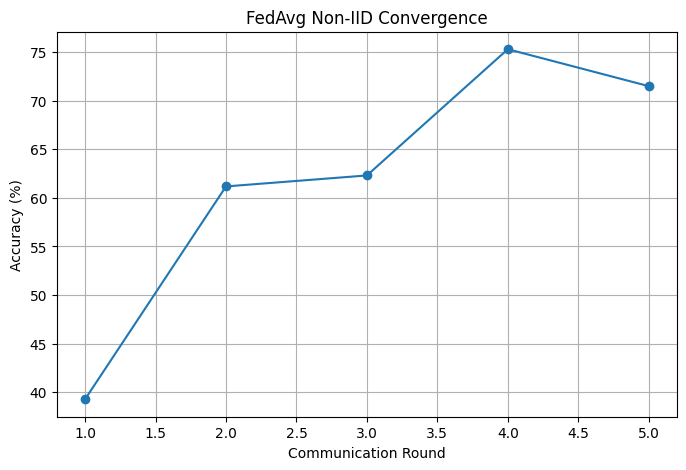

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,ROUNDS+1),
    accuracy_history,
    marker='o'
)

plt.xlabel('Communication Round')
plt.ylabel('Accuracy (%)')
plt.title('FedAvg Non-IID Convergence')

plt.grid()

plt.savefig(
    'fedavg_non_iid_accuracy.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


## Results

In [44]:
CENTRALIZED = 98.93
IID_FL = 99.05

print(f'Centralized Accuracy : {CENTRALIZED:.2f}%')
print(f'FedAvg IID Accuracy  : {IID_FL:.2f}%')
print(f'FedAvg Non-IID       : {accuracy_history[-1]:.2f}%')


Centralized Accuracy : 98.93%
FedAvg IID Accuracy  : 99.05%
FedAvg Non-IID       : 71.50%


## Conclusion

Performance drops significantly under non-IID data distributions.

In our experiment:

- Centralized: 98.93%
- FedAvg IID: 99.05%
- FedAvg Non-IID: ~71.5%

The results highlight the challenge of client drift and motivate algorithms such as FedProx.
